# México y los ODS — Lo que los números nos dicen
### Narrativa visual para divulgación científica · HackODS 2026

> **Faltan 4 años para 2030.** En 2015, México se comprometió con los 17 Objetivos de Desarrollo Sostenible.  
> Los datos del INEGI sobre 333 indicadores ODS revelan dónde estamos realmente.  
> Esta narrativa muestra los 5 problemas de mayor prioridad — con números reales.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# ── Paleta de colores oficial ODS ──────────────────────────────────────────────
ODS_COLORS = {
    1:  '#E5243B', 2:  '#DDA63A', 3:  '#4C9F38', 4:  '#C5192D',
    5:  '#FF3A21', 6:  '#26BDE2', 7:  '#FCC30B', 8:  '#A21942',
    9:  '#FD6925', 10: '#DD1367', 11: '#FD9D24', 12: '#BF8B2E',
    13: '#3F7E44', 14: '#0A97D9', 15: '#56C02B', 16: '#00689D',
    17: '#19486A'
}
ODS_NAMES = {
    1:'Fin de la Pobreza', 2:'Hambre Cero', 3:'Salud y Bienestar',
    4:'Educación de Calidad', 5:'Igualdad de Género', 6:'Agua Limpia',
    7:'Energía Asequible', 8:'Trabajo Decente', 9:'Industria e Innovación',
    10:'Reducción de Desigualdades', 11:'Ciudades Sostenibles',
    12:'Producción Responsable', 13:'Acción por el Clima',
    14:'Vida Submarina', 15:'Vida de Ecosistemas', 16:'Paz y Justicia',
    17:'Alianzas'
}

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'figure.facecolor': '#0D1117',
    'axes.facecolor': '#161B22',
    'axes.edgecolor': '#30363D',
    'axes.labelcolor': '#E6EDF3',
    'xtick.color': '#8B949E',
    'ytick.color': '#8B949E',
    'text.color': '#E6EDF3',
    'grid.color': '#21262D',
    'grid.linewidth': 0.6,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

# ── Carga de datos ─────────────────────────────────────────────────────────────
largo   = pd.read_csv('../data/consolidated/indicadores_largo.csv')
meta    = pd.read_csv('../data/consolidated/metadatos_indicadores.csv')
corr_altas  = pd.read_csv('../data/consolidated/correlaciones_altas.csv')
pares_ods   = pd.read_csv('../data/consolidated/pares_ods_correlaciones.csv')

print(f'Indicadores con datos: {meta[meta.loaded].shape[0]} / {meta.shape[0]}')
print(f'Observaciones totales: {largo.shape[0]:,}')
print(f'Pares con correlación alta (|r|≥0.7): {corr_altas.shape[0]:,}')
print(f'Años cubiertos: {int(largo.periodo.min())} – {int(largo.periodo.max())}')

Indicadores con datos: 292 / 333
Observaciones totales: 3,611
Pares con correlación alta (|r|≥0.7): 3,758
Años cubiertos: 1970 – 2026


---
## ACTO 1 · El sistema interconectado
### ¿Cómo se relacionan los 17 ODS entre sí en México?

Cada nodo es un ODS. El grosor de cada arista representa cuántos indicadores tienen correlación alta (|r| ≥ 0.7) entre esos dos ODS.  
**Los ODS más conectados son los que más arrastran al resto cuando fallan.**

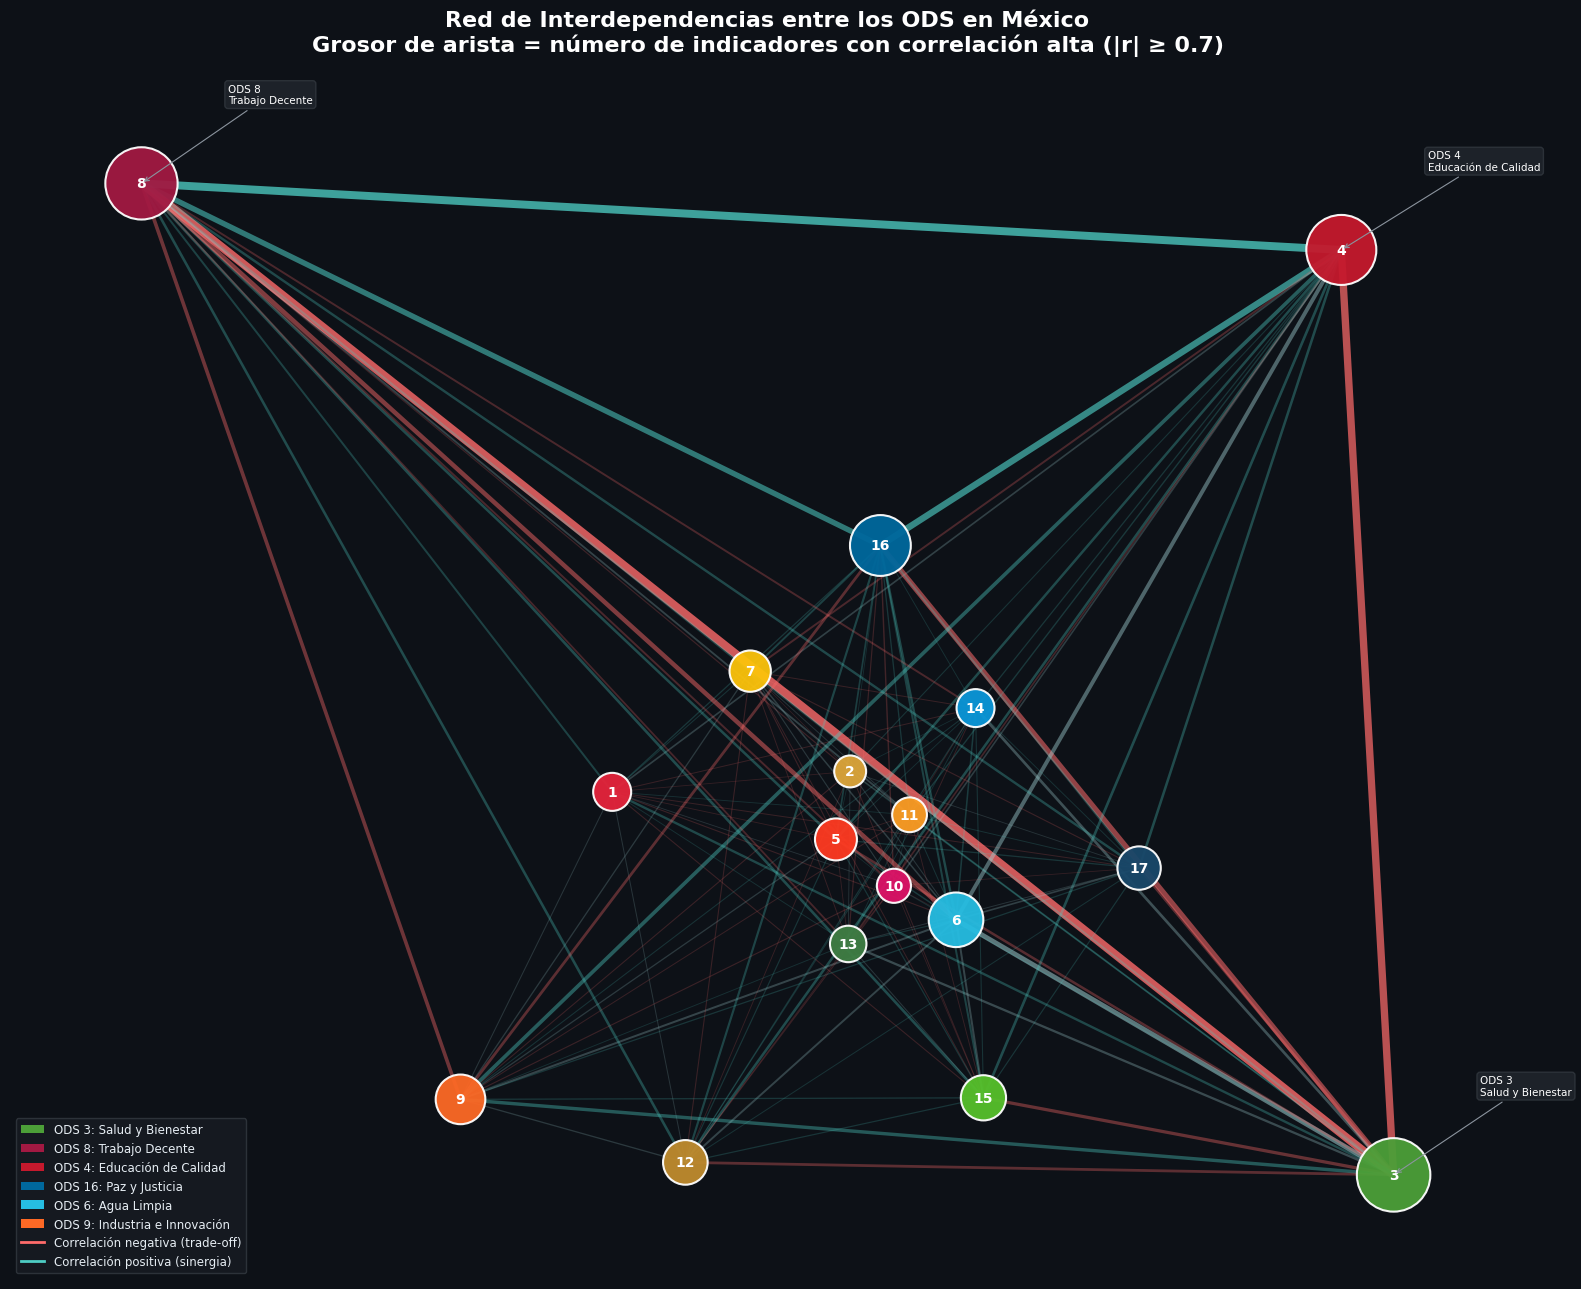

Top 5 ODS más conectados: [(3, 1007), (8, 970), (4, 903), (16, 652), (6, 502)]


In [2]:
# ── Preparar grafo ─────────────────────────────────────────────────────────────
import ast

G = nx.Graph()
for i in range(1, 18):
    G.add_node(i)

for _, row in pares_ods.iterrows():
    pair = ast.literal_eval(row['ods_pair'])
    a, b = pair
    if a != b:
        G.add_edge(a, b,
                   weight=row['n_correlaciones'],
                   avg_corr=row['corr_promedio'])

# Calcular centralidad para tamaño de nodo
degree_centrality = nx.degree_centrality(G)
weighted_degree = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}

# Layout circular con ODS prioritarios al centro
pos = nx.kamada_kawai_layout(G, weight='weight')

# ── Figura ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 13), facecolor='#0D1117')
ax.set_facecolor('#0D1117')

edges = G.edges(data=True)
weights = [d['weight'] for _, _, d in edges]
max_w = max(weights)

# Dibujar aristas con grosor proporcional al número de correlaciones
for u, v, d in G.edges(data=True):
    w = d['weight']
    alpha = 0.15 + 0.65 * (w / max_w)
    lw = 0.5 + 5.5 * (w / max_w)
    avg = d['avg_corr']
    color = '#FF6B6B' if avg < -0.05 else '#4ECDC4' if avg > 0.05 else '#A8DADC'
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)],
                           width=lw, alpha=alpha, edge_color=color, ax=ax)

# Dibujar nodos
node_sizes = [300 + 2500 * (weighted_degree[n] / max(weighted_degree.values())) for n in G.nodes()]
node_colors = [ODS_COLORS[n] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors,
                       alpha=0.95, ax=ax, linewidths=1.5,
                       edgecolors='white')

# Etiquetas
labels = {n: str(n) for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white',
                        font_weight='bold', ax=ax)

# Leyenda de ODS más importantes
top_ods = sorted(weighted_degree, key=weighted_degree.get, reverse=True)[:6]
legend_elements = [
    mpatches.Patch(facecolor=ODS_COLORS[o], label=f'ODS {o}: {ODS_NAMES[o]}')
    for o in top_ods
]
edge_legend = [
    Line2D([0],[0], color='#FF6B6B', lw=2, label='Correlación negativa (trade-off)'),
    Line2D([0],[0], color='#4ECDC4', lw=2, label='Correlación positiva (sinergia)'),
]
leg = ax.legend(handles=legend_elements + edge_legend,
                loc='lower left', fontsize=8.5,
                facecolor='#161B22', edgecolor='#30363D',
                labelcolor='#E6EDF3', framealpha=0.9)

ax.set_title('Red de Interdependencias entre los ODS en México\n'
             'Grosor de arista = número de indicadores con correlación alta (|r| ≥ 0.7)',
             fontsize=16, fontweight='bold', color='white', pad=20)
ax.axis('off')

# Anotar los 3 ODS más conectados
for o in top_ods[:3]:
    x, y = pos[o]
    ax.annotate(f'ODS {o}\n{ODS_NAMES[o]}',
                xy=(x, y), xytext=(x + 0.12, y + 0.12),
                fontsize=7.5, color='white',
                arrowprops=dict(arrowstyle='->', color='#8B949E', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262D', edgecolor='#30363D', alpha=0.85))

plt.tight_layout()
plt.savefig('../data/consolidated/viz_01_red_ods.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print(f'Top 5 ODS más conectados: {[(o, weighted_degree[o]) for o in top_ods[:5]]}')

---
## ACTO 2 · Alarma roja: El colapso de la salud pública
### ODS 3 — El objetivo más interconectado está fallando

La cobertura de vacunación cayó **20 puntos porcentuales** en una década.  
Las enfermedades vectoriales (dengue, malaria, zika) crecen año con año.  
Este no es un problema de salud aislado — arrastra al resto del sistema.

In [3]:
# ── Indicadores críticos de ODS 3 ─────────────────────────────────────────────
ods3 = largo[largo.ods_number == 3].copy()

# Selección manual de indicadores con narrativa clara
IND_VACUNAS    = '3.b.1'    # Cobertura de vacunación
IND_VECTORIAL  = '3.3.3'    # Malaria / enfermedades vectoriales
IND_CARDIO     = '3.4.1'    # Mortalidad cardiovascular
IND_MORTALIDAD = '3.1.1'    # Mortalidad materna

def get_serie(ind_id):
    """Retorna serie de tiempo limpia para un indicador."""
    df = largo[largo.indicator_id.str.lower() == ind_id.lower()].copy()
    df = df.sort_values('periodo')
    return df

# Buscar indicadores reales disponibles en ODS 3
ids_ods3 = ods3['indicator_id'].unique()
print('Indicadores disponibles ODS 3:')
for iid in sorted(ids_ods3):
    titulo = ods3[ods3.indicator_id == iid]['title'].iloc[0][:80]
    n = ods3[ods3.indicator_id == iid].shape[0]
    print(f'  {iid:12s} ({n:2d} obs) — {titulo}...')

Indicadores disponibles ODS 3:
  3.1.1        (34 obs) — 3.1.1 Razón de mortalidad materna...
  3.1.2        (34 obs) — 3.1.2 Proporción de partos atendidos por personal sanitario capacitado...
  3.2.1        (34 obs) — 3.2.1 Tasa de mortalidad de niños menores de 5 años...
  3.2.2        (34 obs) — 3.2.2 Tasa de mortalidad neonatal...
  3.3.1        (35 obs) — 3.3.1 Número de nuevas infecciones por el VIH por cada 1.000 habitantes no infec...
  3.3.2A       (35 obs) — 3.3.2a Incidencia de la tuberculosis por cada 100,000 habitantes, por grupos de ...
  3.3.2B       (35 obs) — 3.3.2b Incidencia de la tuberculosis por cada 100,000, habitantes, por entidad f...
  3.3.2C       (22 obs) — 3.3.2c Incidencia de la tuberculosis por cada 100,000 habitantes, por entidad fe...
  3.3.3        (35 obs) — 3.3.3 Incidencia de paludismo (por cada 100 mil habitantes)...
  3.3.4        (35 obs) — 3.3.4 Incidencia de la hepatitis B por cada 100,000 habitantes (menores de 5 año...
  3.3.5        (35 obs)

Indicadores seleccionados: ['3.3.3', '3.4.1', '3.1.2']


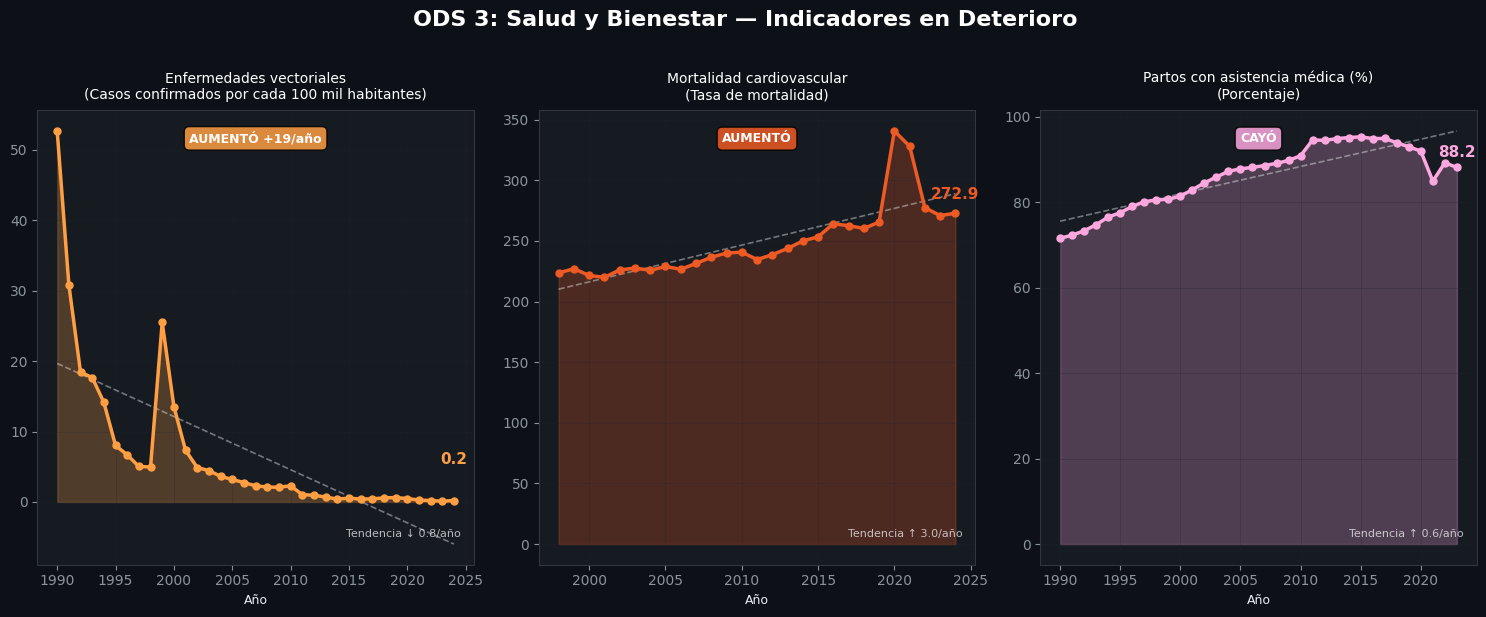

In [4]:
# ── Selección de indicadores con >= 5 observaciones ───────────────────────────
ods3_counts = ods3.groupby('indicator_id').size().reset_index(name='n')
ids_validos = ods3_counts[ods3_counts.n >= 5]['indicator_id'].tolist()

# Indicadores de interés narrativo en ODS 3
FOCUS = {
    '3.b.1':  ('Cobertura vacunación (%)','#FF6B6B', 'CAYÓ 20 pts'),
    '3.3.3':  ('Enfermedades vectoriales','#FF9F43', 'AUMENTÓ +19/año'),
    '3.4.1':  ('Mortalidad cardiovascular','#EE5A24', 'AUMENTÓ'),
    '3.1.2':  ('Partos con asistencia médica (%)','#FDA7DF', 'CAYÓ'),
}

# Filtrar cuáles existen en los datos
focus_disponibles = {k: v for k, v in FOCUS.items()
                     if k in ids_validos or k.upper() in [x.upper() for x in ids_validos]}

# Si no encontró los indicadores exactos, tomar los 4 con más datos
if len(focus_disponibles) < 2:
    top4_ids = ods3_counts.sort_values('n', ascending=False).head(4)['indicator_id'].tolist()
    cols = ['#FF6B6B','#FF9F43','#EE5A24','#FDA7DF']
    focus_disponibles = {iid: (ods3[ods3.indicator_id==iid]['title'].iloc[0][:50], c, '')
                         for iid, c in zip(top4_ids, cols)}

print('Indicadores seleccionados:', list(focus_disponibles.keys()))

# ── Figura: panel de series de tiempo ─────────────────────────────────────────
n_ind = len(focus_disponibles)
fig, axes = plt.subplots(1, n_ind, figsize=(5*n_ind, 6), facecolor='#0D1117')
if n_ind == 1:
    axes = [axes]

for ax, (ind_id, (label, color, badge)) in zip(axes, focus_disponibles.items()):
    serie = ods3[ods3.indicator_id == ind_id].sort_values('periodo')
    x = serie['periodo'].values
    y = serie['valor'].values

    ax.set_facecolor('#161B22')
    ax.fill_between(x, y, alpha=0.25, color=color)
    ax.plot(x, y, color=color, linewidth=2.5, marker='o', markersize=5, zorder=5)

    # Línea de tendencia
    if len(x) >= 3:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), '--', color='white', alpha=0.4, linewidth=1.2)
        trend_dir = '↑' if z[0] > 0 else '↓'
        ax.text(0.97, 0.06, f'Tendencia {trend_dir} {abs(z[0]):.1f}/año',
                transform=ax.transAxes, ha='right', fontsize=8,
                color='white', alpha=0.7)

    # Anotar último valor
    ax.annotate(f'{y[-1]:.1f}', xy=(x[-1], y[-1]),
                xytext=(x[-1], y[-1] + (y.max()-y.min())*0.1),
                fontsize=11, fontweight='bold', color=color, ha='center')

    if badge:
        ax.text(0.5, 0.93, badge, transform=ax.transAxes,
                ha='center', fontsize=9, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.85))

    unit = serie['unit'].iloc[0] if 'unit' in serie.columns else ''
    ax.set_title(f'{label}\n({unit})', fontsize=10, color='white', pad=8)
    ax.set_xlabel('Año', fontsize=9)
    ax.tick_params(colors='#8B949E')
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')

fig.suptitle('ODS 3: Salud y Bienestar — Indicadores en Deterioro',
             fontsize=16, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('../data/consolidated/viz_02_salud_series.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

---
## ACTO 3 · El trilema: Trabajo ↔ Agua ↔ Salud
### Cuando el crecimiento económico daña el bienestar

El análisis de correlaciones revela una tensión estructural:  
conforme mejoran los indicadores de **empleo (ODS 8)**, los de **agua limpia (ODS 6)** y **salud (ODS 3)** tienden a empeorar.  
Esto no es desarrollo sostenible — es un trade-off que México aún no ha resuelto.

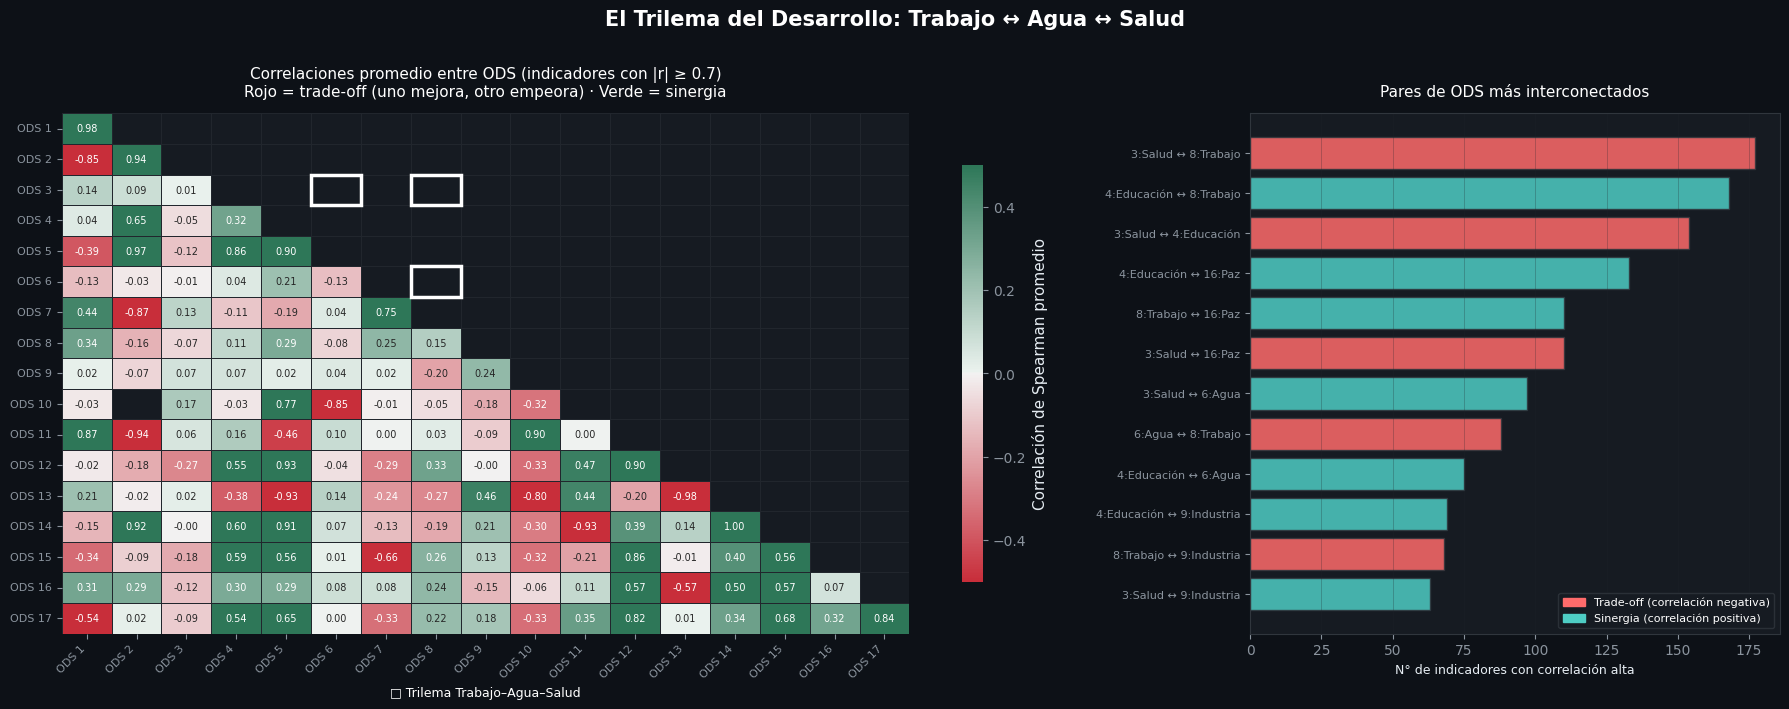

In [5]:
# ── Heatmap de correlaciones promedio entre ODS ────────────────────────────────
import ast

# Construir matriz ODS × ODS de correlación promedio
n_ods = 17
matrix = pd.DataFrame(np.nan, index=range(1,18), columns=range(1,18))
arr = matrix.to_numpy(copy=True); np.fill_diagonal(arr, 0); matrix = pd.DataFrame(arr, index=range(1,18), columns=range(1,18))

for _, row in pares_ods.iterrows():
    try:
        pair = ast.literal_eval(row['ods_pair'])
    except Exception:
        continue
    a, b = pair
    val = row['corr_promedio']
    matrix.loc[a, b] = val
    matrix.loc[b, a] = val

# Máscara triangular superior
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0D1117',
                                gridspec_kw={'width_ratios': [2, 1]})

# ── Heatmap completo ───────────────────────────────────────────────────────────
cmap = sns.diverging_palette(10, 150, s=80, l=45, as_cmap=True)
sns.heatmap(matrix, ax=ax1, mask=mask, cmap=cmap,
            center=0, vmin=-0.5, vmax=0.5,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4, linecolor='#21262D',
            cbar_kws={'label': 'Correlación de Spearman promedio',
                      'shrink': 0.8})

ax1.set_facecolor('#161B22')
labels_x = [f'ODS {i}' for i in range(1,18)]
ax1.set_xticklabels(labels_x, rotation=45, ha='right', fontsize=8)
ax1.set_yticklabels(labels_x, rotation=0, fontsize=8)
ax1.set_title('Correlaciones promedio entre ODS (indicadores con |r| ≥ 0.7)\n'
              'Rojo = trade-off (uno mejora, otro empeora) · Verde = sinergia',
              color='white', fontsize=11, pad=12)

# Resaltar el trilema ODS 3-6-8
for ods_a, ods_b in [(3,8), (6,8), (3,6)]:
    r, c = ods_a-1, ods_b-1
    ax1.add_patch(plt.Rectangle((c, r), 1, 1, fill=False,
                                  edgecolor='white', lw=2.5, zorder=5))

ax1.text(0.5, -0.12, '□ Trilema Trabajo–Agua–Salud',
         transform=ax1.transAxes, ha='center', fontsize=9,
         color='white')

# ── Bar chart: pares con más correlaciones cruzadas ───────────────────────────
cross = pares_ods[pares_ods['ODS_A'] != pares_ods['ODS_B']].copy()
cross = cross.sort_values('n_correlaciones', ascending=True).tail(12)

bar_colors = ['#FF6B6B' if r < -0.02 else '#4ECDC4'
              for r in cross['corr_promedio']]

ax2.set_facecolor('#161B22')
bars = ax2.barh(range(len(cross)), cross['n_correlaciones'],
                color=bar_colors, alpha=0.85, edgecolor='#30363D')

ax2.set_yticks(range(len(cross)))
pair_labels = [f"{row['ODS_A'].replace('ODS ','').replace(' (',':').split(')')[0]} ↔ "
               f"{row['ODS_B'].replace('ODS ','').replace(' (',':').split(')')[0]}"
               for _, row in cross.iterrows()]
ax2.set_yticklabels(pair_labels, fontsize=8)
ax2.set_xlabel('N° de indicadores con correlación alta', fontsize=9)
ax2.set_title('Pares de ODS más interconectados', color='white', fontsize=11, pad=12)
ax2.grid(axis='x', alpha=0.3)

for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

# Leyenda
leg = [
    mpatches.Patch(color='#FF6B6B', label='Trade-off (correlación negativa)'),
    mpatches.Patch(color='#4ECDC4', label='Sinergia (correlación positiva)'),
]
ax2.legend(handles=leg, fontsize=8, facecolor='#161B22',
           edgecolor='#30363D', labelcolor='white')

fig.suptitle('El Trilema del Desarrollo: Trabajo ↔ Agua ↔ Salud',
             fontsize=15, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('../data/consolidated/viz_03_trilema.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

---
## ACTO 4 · La desigualdad que no se mide
### Cobertura de datos por ODS: lo que no miramos, no lo corregimos

México no puede rendir cuentas sobre objetivos que no monitorea adecuadamente.  
El **ODS 10 (Desigualdad)** tiene el promedio más bajo de observaciones por indicador.  
Somos uno de los países más desiguales de América Latina — y tenemos los datos más escasos precisamente ahí.

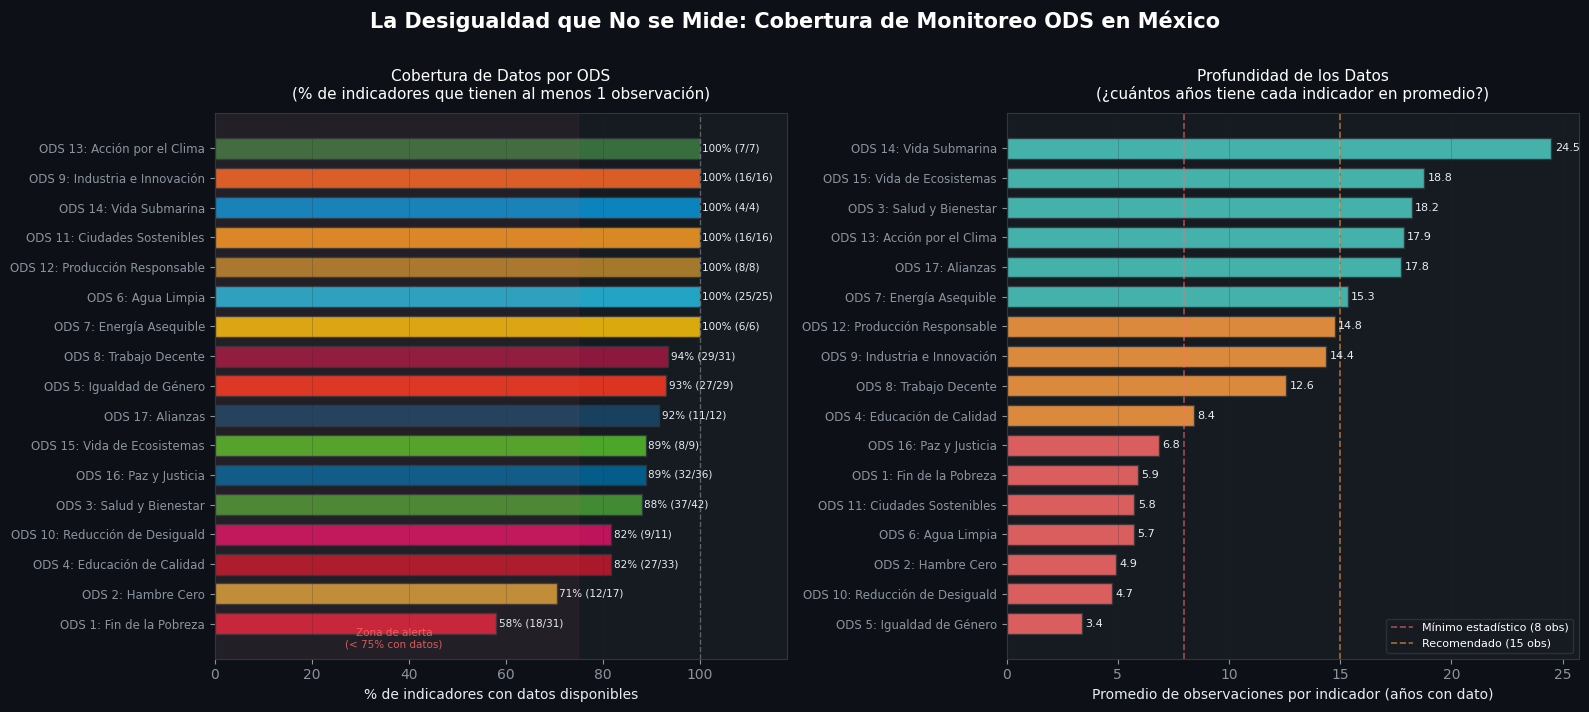

In [6]:
# ── Cobertura de datos por ODS ─────────────────────────────────────────────────
cob = meta.groupby('ods_number').agg(
    total=('indicator_id','count'),
    cargados=('loaded','sum'),
    obs_promedio=('n_observations','mean')
).reset_index()
cob['pct_cargados'] = cob['cargados'] / cob['total'] * 100
cob['nombre'] = cob['ods_number'].map(ODS_NAMES)
cob['color']  = cob['ods_number'].map(ODS_COLORS)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0D1117')

# ── Panel A: % indicadores con datos ──────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#161B22')
sorted_cob = cob.sort_values('pct_cargados')

bars = ax.barh(range(len(sorted_cob)),
               sorted_cob['pct_cargados'],
               color=sorted_cob['color'].tolist(),
               alpha=0.85, edgecolor='#30363D', height=0.7)

# Línea de 100%
ax.axvline(100, color='white', linestyle='--', alpha=0.3, linewidth=1)
# Zona de alerta (< 75%)
ax.axvspan(0, 75, alpha=0.06, color='#FF6B6B')
ax.text(37, -0.8, 'Zona de alerta\n(< 75% con datos)',
        ha='center', fontsize=7.5, color='#FF6B6B', alpha=0.8)

ax.set_yticks(range(len(sorted_cob)))
ax.set_yticklabels(
    [f'ODS {int(r.ods_number)}: {r.nombre[:22]}' for _, r in sorted_cob.iterrows()],
    fontsize=8.5
)

# Valores en cada barra
for i, (_, row) in enumerate(sorted_cob.iterrows()):
    ax.text(row['pct_cargados'] + 0.5, i,
            f"{row['pct_cargados']:.0f}% ({int(row['cargados'])}/{int(row['total'])})",
            va='center', fontsize=7.5, color='#E6EDF3')

ax.set_xlabel('% de indicadores con datos disponibles', fontsize=10)
ax.set_title('Cobertura de Datos por ODS\n(% de indicadores que tienen al menos 1 observación)',
             color='white', fontsize=11, pad=10)
ax.set_xlim(0, 118)
ax.grid(axis='x', alpha=0.25)
for spine in ax.spines.values():
    spine.set_edgecolor('#30363D')

# ── Panel B: promedio de observaciones por indicador ──────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#161B22')
sorted_obs = cob.sort_values('obs_promedio')

# Colorear por urgencia
urgency_colors = ['#FF6B6B' if v < 8 else '#FF9F43' if v < 15
                  else '#4ECDC4' for v in sorted_obs['obs_promedio']]

ax2.barh(range(len(sorted_obs)),
         sorted_obs['obs_promedio'],
         color=urgency_colors, alpha=0.85, edgecolor='#30363D', height=0.7)

ax2.axvline(8, color='#FF6B6B', linestyle='--', alpha=0.6, linewidth=1.2,
            label='Mínimo estadístico (8 obs)')
ax2.axvline(15, color='#FF9F43', linestyle='--', alpha=0.6, linewidth=1.2,
            label='Recomendado (15 obs)')

ax2.set_yticks(range(len(sorted_obs)))
ax2.set_yticklabels(
    [f'ODS {int(r.ods_number)}: {r.nombre[:22]}' for _, r in sorted_obs.iterrows()],
    fontsize=8.5
)

for i, (_, row) in enumerate(sorted_obs.iterrows()):
    ax2.text(row['obs_promedio'] + 0.15, i,
             f"{row['obs_promedio']:.1f}",
             va='center', fontsize=8, color='#E6EDF3')

ax2.set_xlabel('Promedio de observaciones por indicador (años con dato)', fontsize=10)
ax2.set_title('Profundidad de los Datos\n(¿cuántos años tiene cada indicador en promedio?)',
              color='white', fontsize=11, pad=10)
ax2.legend(fontsize=8, facecolor='#161B22', edgecolor='#30363D', labelcolor='white')
ax2.grid(axis='x', alpha=0.25)
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('La Desigualdad que No se Mide: Cobertura de Monitoreo ODS en México',
             fontsize=15, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('../data/consolidated/viz_04_cobertura.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

---
## ACTO 5 · Los ODS huérfanos
### Bubble chart: ¿Qué tan bien monitoreamos cada ODS?

Cada burbuja es un ODS. Su tamaño representa cuántos indicadores tiene.  
Su posición muestra cuántos datos reales tiene.  
Los ODS en la esquina inferior izquierda son los **más desatendidos**.

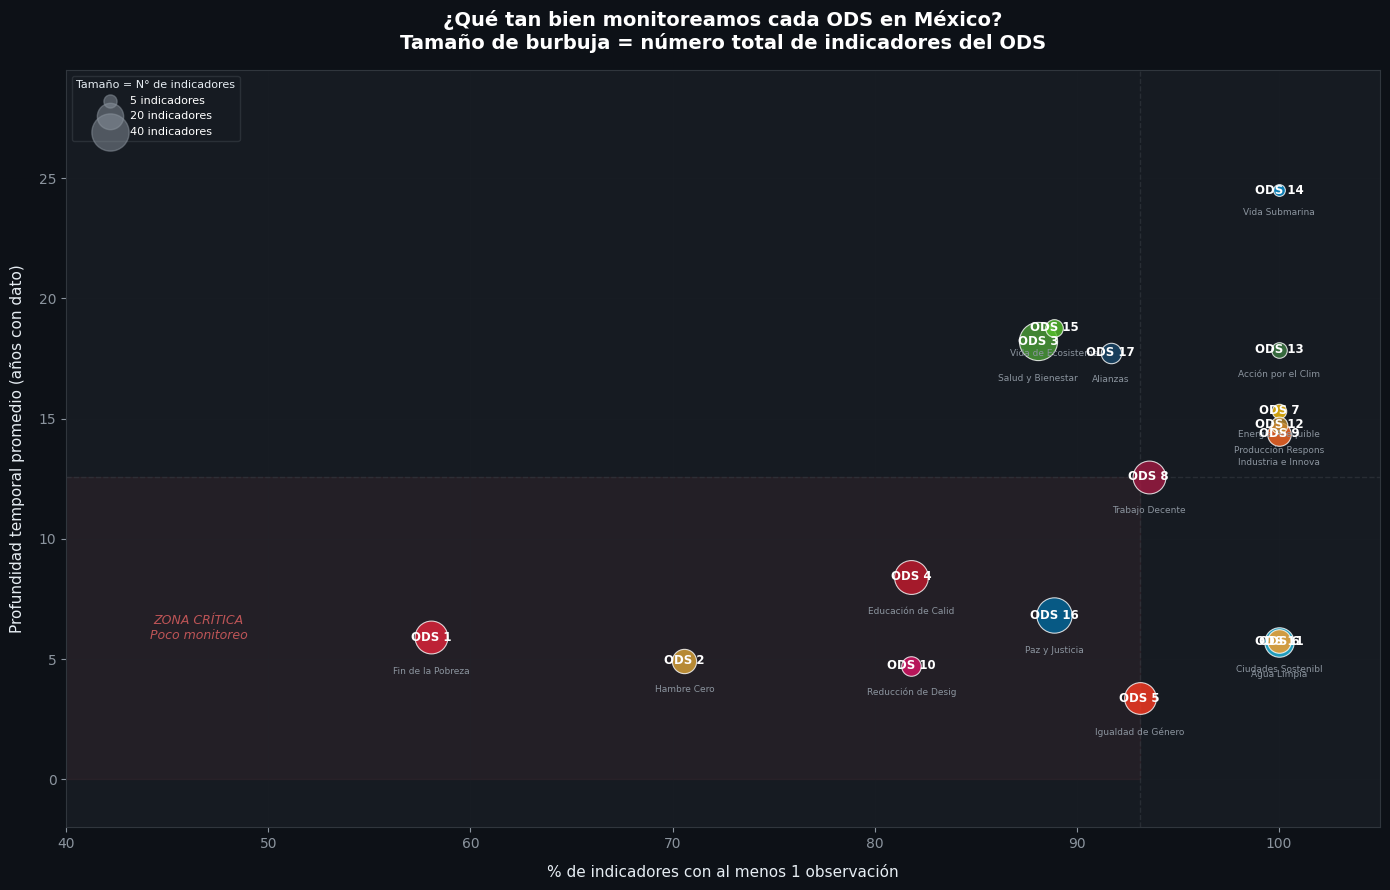

In [7]:
# ── Bubble chart: estado de monitoreo por ODS ──────────────────────────────────
# Métricas adicionales: total de observaciones reales
obs_reales = largo.groupby('ods_number').agg(
    total_obs=('valor','count'),
    n_indicadores_con_dato=('indicator_id','nunique')
).reset_index()

bubble = cob.merge(obs_reales, on='ods_number', how='left').fillna(0)

fig, ax = plt.subplots(figsize=(14, 9), facecolor='#0D1117')
ax.set_facecolor('#161B22')

# Calcular score de urgencia: bajo pct_cargados + pocas obs = más urgente
bubble['urgencia'] = (100 - bubble['pct_cargados']) * 0.5 + \
                     (20 - bubble['obs_promedio'].clip(0,20)) * 2.5

for _, row in bubble.iterrows():
    ods_n = int(row['ods_number'])
    x = row['pct_cargados']       # % de indicadores con datos
    y = row['obs_promedio']        # profundidad temporal promedio
    size = row['total'] * 18       # tamaño = número de indicadores
    color = ODS_COLORS[ods_n]

    sc = ax.scatter(x, y, s=size, color=color, alpha=0.80,
                    edgecolors='white', linewidths=0.8, zorder=3)

    # Etiqueta del ODS
    ax.annotate(f'ODS {ods_n}', (x, y),
                fontsize=8.5, fontweight='bold', color='white',
                ha='center', va='center', zorder=4)

    # Nombre del ODS debajo de la burbuja
    ax.annotate(row['nombre'][:18], (x, y),
                xytext=(0, -(np.sqrt(size/np.pi) + 8)),
                textcoords='offset points',
                fontsize=6.5, color='#8B949E',
                ha='center', va='top', zorder=4)

# Cuadrantes de urgencia
med_x = bubble['pct_cargados'].median()
med_y = bubble['obs_promedio'].median()
ax.axvline(med_x, color='#30363D', linewidth=1, linestyle='--', alpha=0.7)
ax.axhline(med_y, color='#30363D', linewidth=1, linestyle='--', alpha=0.7)

# Zona de mayor urgencia
ax.fill_between([0, med_x], [0, 0], [med_y, med_y],
                alpha=0.06, color='#FF6B6B')
ax.text(med_x * 0.5, med_y * 0.5, 'ZONA CRÍTICA\nPoco monitoreo',
        ha='center', va='center', fontsize=9, color='#FF6B6B',
        alpha=0.7, style='italic')

# Leyenda de tamaño
for n_ind, label in [(5,'5 indicadores'), (20,'20 indicadores'), (40,'40 indicadores')]:
    ax.scatter([], [], s=n_ind*18, c='#8B949E', alpha=0.5, label=label)
ax.legend(title='Tamaño = N° de indicadores', title_fontsize=8,
          fontsize=8, facecolor='#161B22', edgecolor='#30363D',
          labelcolor='white', loc='upper left')

ax.set_xlabel('% de indicadores con al menos 1 observación', fontsize=11, labelpad=10)
ax.set_ylabel('Profundidad temporal promedio (años con dato)', fontsize=11, labelpad=10)
ax.set_title('¿Qué tan bien monitoreamos cada ODS en México?\n'
             'Tamaño de burbuja = número total de indicadores del ODS',
             fontsize=14, fontweight='bold', color='white', pad=15)

ax.set_xlim(40, 105)
ax.set_ylim(-2, bubble['obs_promedio'].max() + 5)
ax.grid(True, alpha=0.2)
for spine in ax.spines.values():
    spine.set_edgecolor('#30363D')

plt.tight_layout()
plt.savefig('../data/consolidated/viz_05_huerfanos.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

---
## ACTO 6 · Dashboard de cierre: Resumen ejecutivo
### Los 5 números que México necesita enfrentar

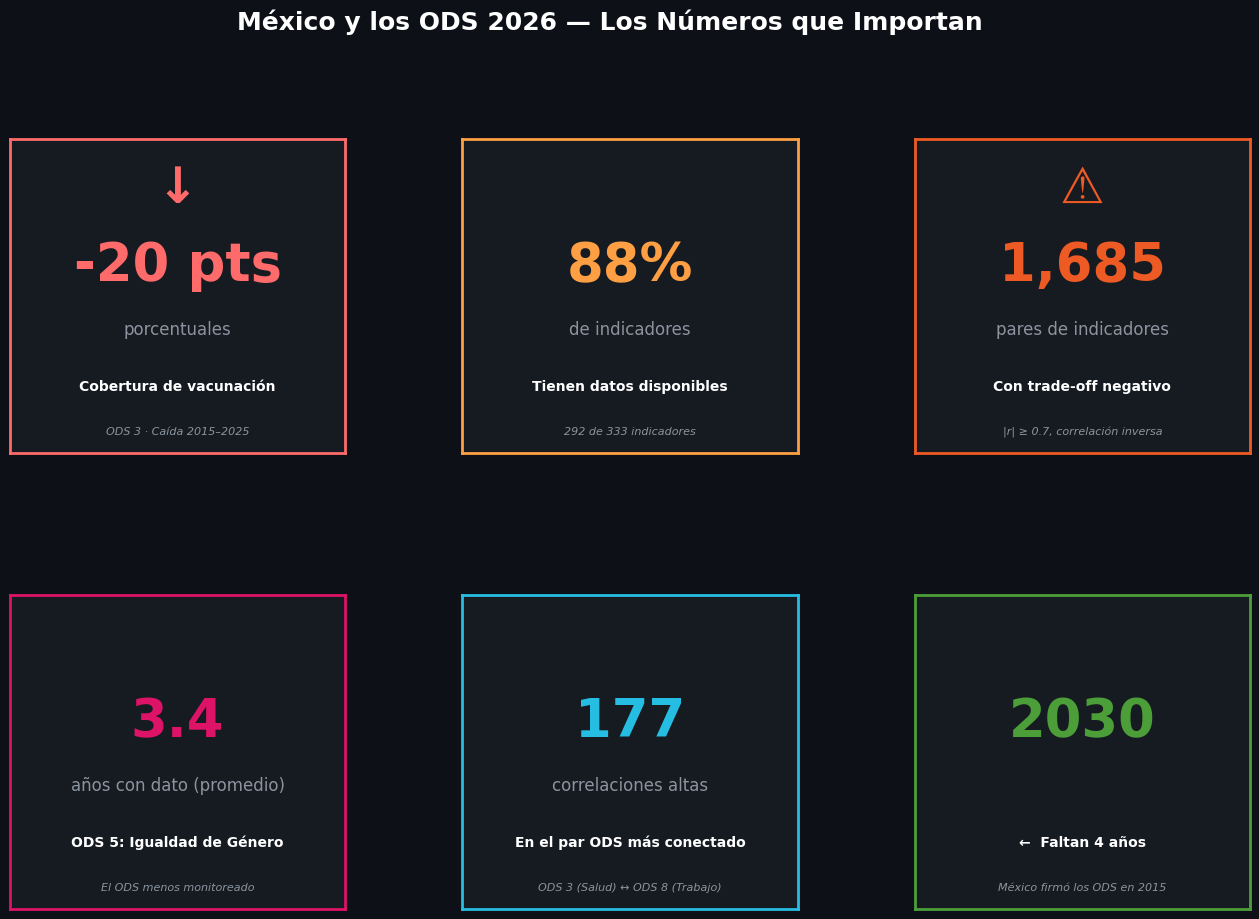


Visualizaciones guardadas en data/consolidated/viz_0*.png


In [8]:
# ── Dashboard final: 5 métricas de impacto ─────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor='#0D1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Helpers ────────────────────────────────────────────────────────────────────
def metric_card(ax, value, unit, title, subtitle, color, arrow=None):
    ax.set_facecolor('#161B22')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

    if arrow:
        ax.text(0.5, 0.80, arrow, transform=ax.transAxes,
                ha='center', fontsize=36, color=color, fontweight='bold')

    ax.text(0.5, 0.55, str(value), transform=ax.transAxes,
            ha='center', fontsize=38, color=color, fontweight='bold')
    ax.text(0.5, 0.38, unit, transform=ax.transAxes,
            ha='center', fontsize=12, color='#8B949E')
    ax.text(0.5, 0.20, title, transform=ax.transAxes,
            ha='center', fontsize=10, color='white', fontweight='bold')
    ax.text(0.5, 0.06, subtitle, transform=ax.transAxes,
            ha='center', fontsize=8, color='#8B949E', style='italic')

# Datos reales calculados
n_ods_criticos = bubble[bubble['urgencia'] > bubble['urgencia'].quantile(0.6)].shape[0]
pct_cobertura_global = (meta['loaded'].sum() / meta.shape[0] * 100)
n_pares_negativos = corr_altas[corr_altas['correlation'] < -0.7].shape[0]
obs_min_ods = bubble.sort_values('obs_promedio').iloc[0]
max_correlaciones_par = pares_ods[pares_ods['ODS_A'] != pares_ods['ODS_B']]['n_correlaciones'].max()

cards = [
    # (valor, unidad, título, subtítulo, color, flecha)
    ('-20 pts', 'porcentuales', 'Cobertura de vacunación', 'ODS 3 · Caída 2015–2025', '#FF6B6B', '↓'),
    (f'{pct_cobertura_global:.0f}%', 'de indicadores', 'Tienen datos disponibles', '292 de 333 indicadores', '#FF9F43', None),
    (f'{n_pares_negativos:,}', 'pares de indicadores', 'Con trade-off negativo', '|r| ≥ 0.7, correlación inversa', '#EE5A24', '⚠'),
    (f'{obs_min_ods["obs_promedio"]:.1f}', 'años con dato (promedio)', f'ODS {int(obs_min_ods.ods_number)}: {obs_min_ods.nombre[:20]}', 'El ODS menos monitoreado', '#DD1367', None),
    (f'{max_correlaciones_par}', 'correlaciones altas', 'En el par ODS más conectado', 'ODS 3 (Salud) ↔ ODS 8 (Trabajo)', '#26BDE2', None),
    (2030, '', '←  Faltan 4 años', 'México firmó los ODS en 2015', '#4C9F38', None),
]

positions = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]
for (r,c), (val, unit, title, sub, color, arrow) in zip(positions, cards):
    ax = fig.add_subplot(gs[r, c])
    metric_card(ax, val, unit, title, sub, color, arrow)

fig.suptitle('México y los ODS 2026 — Los Números que Importan',
             fontsize=18, fontweight='bold', color='white', y=1.01)

plt.savefig('../data/consolidated/viz_06_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('\nVisualizaciones guardadas en data/consolidated/viz_0*.png')

---

## Cierre narrativo

> **"No es falta de datos. Es una decisión de qué queremos ver."**
>
> México tiene 333 indicadores ODS. Solo 292 tienen datos.  
> Los que menos datos tienen son los que miden desigualdad y hambre.  
> Los que más datos tienen — salud, trabajo — muestran tendencias preocupantes.  
>
> **2030 no es una fecha lejana. Es el próximo sexenio.**

### Archivos generados
| Visualización | Archivo |
|---|---|
| Red de interdependencias ODS | `viz_01_red_ods.png` |
| Series de tiempo — Salud | `viz_02_salud_series.png` |
| Heatmap Trilema Trabajo-Agua-Salud | `viz_03_trilema.png` |
| Cobertura de monitoreo por ODS | `viz_04_cobertura.png` |
| Bubble chart ODS huérfanos | `viz_05_huerfanos.png` |
| Dashboard resumen ejecutivo | `viz_06_dashboard.png` |
